# Chromatic Aberration — a singlet that fails, and the achromat that fixes it

Every other notebook here traces a system at one wavelength. This one is
about what happens when you don't: glass index falls with wavelength, so a
lens has a *different focal length for every colour*, and the resulting
blur is often the largest single error in a simple lens.

Two deliberately matched systems, both ~100 mm focal length at f/8, both
with the object effectively at infinity:

| | construction | why |
|---|---|---|
| **SF11 singlet** | one equiconvex N-SF11 element | N-SF11 is a *dense flint*: V<sub>d</sub> = 25.7, among the most dispersive common glasses. Deliberately the worst reasonable case. |
| **BK7/SF11 achromat** | cemented N-BK7 crown + N-SF11 flint | The classical fix: a weak flint negative element cancels the crown's colour spread while leaving most of its focusing power. |

Both are stored as ordinary prescriptions in `raytracer/data/`, so the
analysis below is the same code path any other lens in this package gets.

The achromat's radii come from the textbook thin-lens achromat condition:
with total power $K = K_1 + K_2$, cancelling first-order colour requires
$K_1/V_1 + K_2/V_2 = 0$, giving $K_1 = K\,V_1/(V_1-V_2)$ and
$K_2 = -K\,V_2/(V_1-V_2)$.

In [1]:
import copy

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from importlib import resources

from raytracer.core.materials import default_materials
from raytracer.sequential import OpticalSystem, ParaxialModel
from raytracer.analysis import axial_color, chromatic_spots, lateral_color
from raytracer.viz import plots

# Fraunhofer reference lines: F (blue H), d (yellow He), C (red H). The Abbe
# number V_d = (n_d - 1) / (n_F - n_C) is defined on exactly these three.
F_LINE, D_LINE, C_LINE = 0.48613, 0.58756, 0.65627
REFERENCE_LINES = (F_LINE, D_LINE, C_LINE)

# The object plane both designs were solved for: far enough away to stand in
# for infinity, close enough to stay an ordinary finite-conjugate trace.
OBJECT_Z_MM = -1.0e5
SEMIDIAMETER_MM = 6.25                      # stop radius -> f/8 at f = 100 mm
NA_OBJECT = SEMIDIAMETER_MM / abs(OBJECT_Z_MM)

DATA = resources.files("raytracer") / "data"

def load(filename, name):
    system = OpticalSystem.from_prescription(DATA / filename)
    system.object_z = OBJECT_Z_MM           # infinite-conjugate designs carry no object plane
    system.name = name
    return system

singlet = load("sf11_singlet_prescription.csv", "SF11 singlet")
achromat = load("bk7_sf11_achromat_prescription.csv", "BK7/SF11 achromat")

for system in (singlet, achromat):
    print(f"{system.name:20s} {len(system)} surfaces  "
          f"EFL = {ParaxialModel(system).effective_focal_length():7.3f} mm  "
          f"image plane z = {system.image_z:8.3f} mm")

SF11 singlet         3 surfaces  EFL = 100.848 mm  image plane z =  130.254 mm
BK7/SF11 achromat    4 surfaces  EFL = 101.148 mm  image plane z =  132.238 mm


## 1 · The glasses

`N-BK7` and `N-SF11` both resolve to `SellmeierMaterial` — the
manufacturer's measured 3-term dispersion curve, not an approximation.
The two curves are the whole story in miniature: the flint is both higher
index *and* much steeper, and it is the steepness (dispersion) that
causes chromatic aberration, not the index itself.

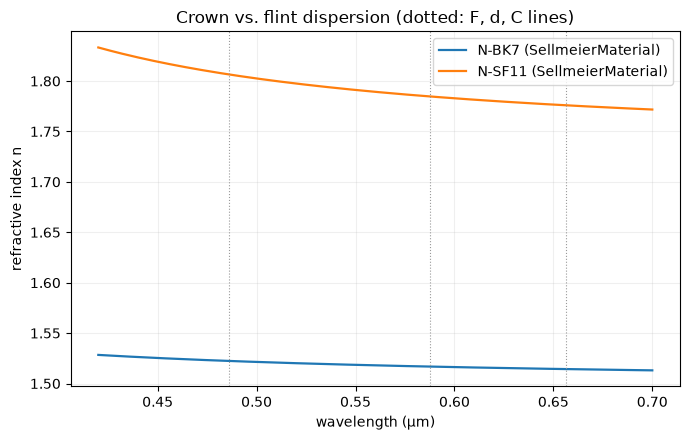

glass            n_F       n_d       n_C   n_F - n_C     V_d
N-BK7        1.52238   1.51680   1.51432     0.00805   64.17
N-SF11       1.80651   1.78472   1.77596     0.03056   25.68


In [2]:
materials = default_materials()
glasses = [materials.resolve("N-BK7"), materials.resolve("N-SF11")]
wavelengths = np.linspace(0.42, 0.70, 141)

fig = plots.dispersion_figure(glasses, wavelengths, reference_lines_um=REFERENCE_LINES,
                              title="Crown vs. flint dispersion (dotted: F, d, C lines)")
plt.show()

print(f"{'glass':10s} {'n_F':>9s} {'n_d':>9s} {'n_C':>9s} {'n_F - n_C':>11s} {'V_d':>7s}")
for glass in glasses:
    n_f, n_d, n_c = (glass.index(w) for w in REFERENCE_LINES)
    print(f"{glass.name:10s} {n_f:9.5f} {n_d:9.5f} {n_c:9.5f} {n_f - n_c:11.5f} "
          f"{(n_d - 1) / (n_f - n_c):7.2f}")

## 2 · Axial colour — where each colour focuses

Trace each wavelength through the same prescription and find its paraxial
focus. The singlet's focus marches steadily with wavelength; the
achromat's barely moves.

Note the *shape*, not just the size. The singlet's curve is monotonic —
there is no wavelength pair that shares a focus. The achromat's is a
shallow parabola: it is designed so F and C land together, and what
remains (the residual bow, its minimum near the middle of the band) is the
**secondary spectrum**, the part a two-glass achromat cannot remove.

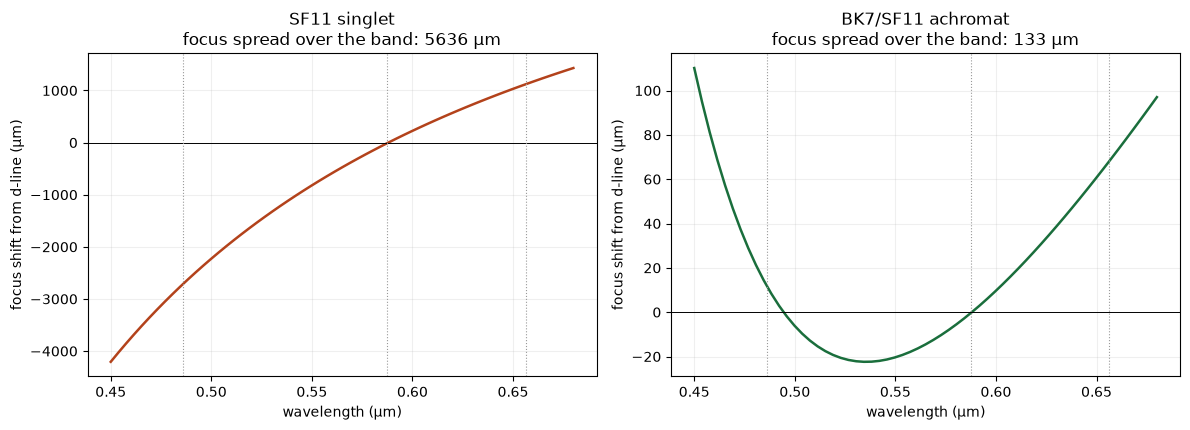

SF11 singlet         F-to-C focus difference =   -3825.6 µm
BK7/SF11 achromat    F-to-C focus difference =     -56.2 µm


In [3]:
sweep = np.linspace(0.45, 0.68, 61)
axial = {s.name: axial_color(s, sweep, reference_wavelength_um=D_LINE)
         for s in (singlet, achromat)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, (name, result), color in zip(axes, axial.items(), ("#b3421b", "#1a6e3c")):
    ax.plot(result.wavelengths_um, result.focus_shift_mm * 1e3, "-", color=color, lw=1.8)
    ax.axhline(0, color="black", lw=0.7)
    for line in REFERENCE_LINES:
        ax.axvline(line, color="#999999", ls=":", lw=0.8)
    span = np.ptp(result.focus_shift_mm) * 1e3
    ax.set(xlabel="wavelength (µm)", ylabel="focus shift from d-line (µm)",
           title=f"{name}\nfocus spread over the band: {span:.0f} µm")
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

for name, result in axial.items():
    f_c = np.interp(F_LINE, result.wavelengths_um, result.focus_shift_mm)
    c_c = np.interp(C_LINE, result.wavelengths_um, result.focus_shift_mm)
    print(f"{name:20s} F-to-C focus difference = {(f_c - c_c) * 1e3:+9.1f} µm")

### The achromat on its own scale

Plotted alone, the residual is unmistakably the classic secondary
spectrum: F and C cross zero together, and the curve bows away in between.
A two-glass achromat corrects *first-order* colour, which is why the
residual is a bow rather than a slope.

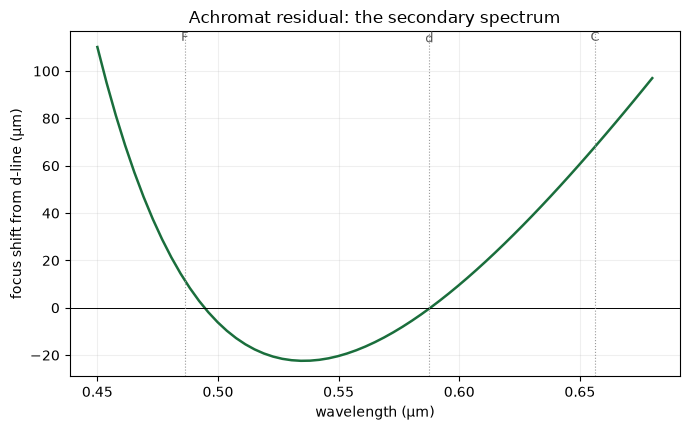

residual extremum near 534 nm — between the F and C lines the design forces together


In [4]:
result = axial["BK7/SF11 achromat"]
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(result.wavelengths_um, result.focus_shift_mm * 1e3, "-", color="#1a6e3c", lw=1.8)
ax.axhline(0, color="black", lw=0.7)
for line, label in zip(REFERENCE_LINES, ("F", "d", "C")):
    ax.axvline(line, color="#999999", ls=":", lw=0.8)
    ax.annotate(label, (line, ax.get_ylim()[1]), ha="center", va="top", fontsize=9,
                color="#555555")
ax.set(xlabel="wavelength (µm)", ylabel="focus shift from d-line (µm)",
       title="Achromat residual: the secondary spectrum")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

crossing = result.wavelengths_um[np.argmin(result.focus_shift_mm)]
print(f"residual extremum near {crossing * 1e3:.0f} nm — between the F and C lines "
      f"the design forces together")

## 3 · What it looks like on the detector

Axial colour is a curve; this is the thing itself. Every wavelength is
traced onto the **same** image plane — the d-line focus — because a real
detector sits at one place and receives all colours at once.

All wavelengths are also referred to one **common origin**, which is the
whole point of `chromatic_spots`: recentring each colour on its own
centroid (what a normal monochromatic spot diagram does, correctly) would
subtract out exactly the colour separation being measured.

Both panels share axis limits, so the comparison is honest.

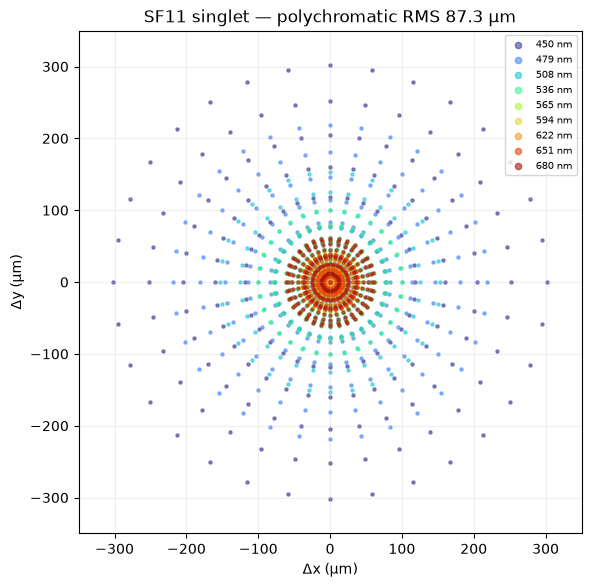

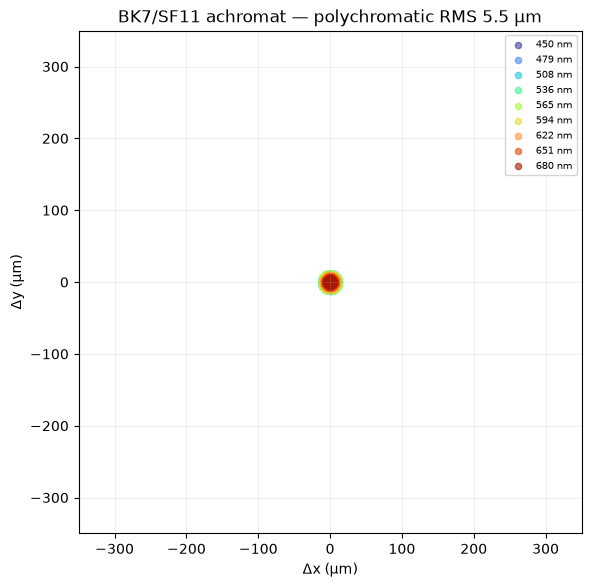

 wavelength         SF11     BK7/SF11
     450 nm       186.1 µm         2.3 µm
     479 nm       133.7 µm         5.0 µm
     508 nm        92.2 µm         6.5 µm
     536 nm        58.6 µm         7.0 µm
     565 nm        31.0 µm         6.9 µm
     594 nm         8.8 µm         6.3 µm
     622 nm        13.6 µm         5.4 µm
     651 nm        30.1 µm         4.5 µm
     680 nm        44.8 µm         3.5 µm

SF11 singlet         polychromatic RMS =   87.30 µm
BK7/SF11 achromat    polychromatic RMS =    5.49 µm


In [5]:
spot_wavelengths = np.linspace(0.45, 0.68, 9)
spots = {s.name: chromatic_spots(s, spot_wavelengths, na_object_sine=NA_OBJECT,
                                 reference_wavelength_um=D_LINE, field=0.0)
         for s in (singlet, achromat)}

LIMIT_UM = 350.0
for name, result in spots.items():
    fig = plots.chromatic_spots_figure(
        result, limit_um=LIMIT_UM,
        title=f"{name} — polychromatic RMS {result.polychromatic_rms_um:.1f} µm",
    )
    plt.show()

print(f"{'wavelength':>11s} " + " ".join(f"{n.split()[0]:>12s}" for n in spots))
for i, w in enumerate(spot_wavelengths):
    row = "  ".join(f"{r.rms_radius_um[i]:10.1f} µm" for r in spots.values())
    print(f"{w * 1e3:8.0f} nm  {row}")
print()
for name, result in spots.items():
    print(f"{name:20s} polychromatic RMS = {result.polychromatic_rms_um:7.2f} µm")

The singlet's blue rays land ~300 µm off axis while its red rays are
nearly in focus — the spot is a *colour-graded halo*, not a point. That is
the visual signature of axial colour, and at f/8 it dwarfs every other
aberration in the system.

The achromat, same scale, is a dot.

## 4 · No focus setting rescues the singlet

A natural question is whether the singlet is simply focused wrongly. It
isn't: refocusing trades one colour's sharpness for another's, because the
colours' focal planes are genuinely in different places. Sweeping the
image plane through focus shows the polychromatic blur has a floor it
never gets under.

SF11 singlet         best white-light RMS =   72.86 µm at defocus -1.25 mm
BK7/SF11 achromat    best white-light RMS =    5.49 µm at defocus +0.00 mm


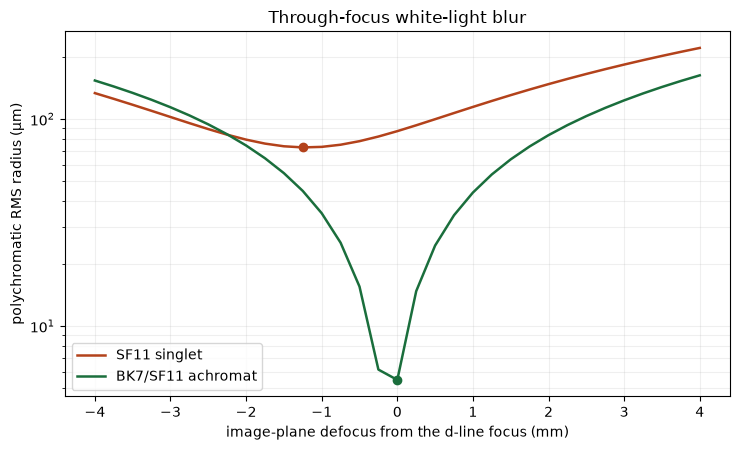

In [6]:
def defocused(system, delta_z_mm):
    """A copy of *system* with its image plane moved by delta_z_mm."""
    shifted = copy.deepcopy(system)
    shifted.set_thickness(len(shifted.rows) - 1,
                          shifted.rows[-1].thickness + delta_z_mm)
    return shifted


defocus_mm = np.linspace(-4.0, 4.0, 33)
through_focus = {
    s.name: np.array([
        chromatic_spots(defocused(s, dz), spot_wavelengths, na_object_sine=NA_OBJECT,
                        reference_wavelength_um=D_LINE).polychromatic_rms_um
        for dz in defocus_mm
    ])
    for s in (singlet, achromat)
}

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for (name, rms), color in zip(through_focus.items(), ("#b3421b", "#1a6e3c")):
    ax.plot(defocus_mm, rms, "-", color=color, lw=1.8, label=name)
    best = defocus_mm[np.argmin(rms)]
    ax.plot([best], [rms.min()], "o", color=color, ms=6)
    print(f"{name:20s} best white-light RMS = {rms.min():7.2f} µm "
          f"at defocus {best:+.2f} mm")
ax.set(xlabel="image-plane defocus from the d-line focus (mm)",
       ylabel="polychromatic RMS radius (µm)", yscale="log",
       title="Through-focus white-light blur")
ax.grid(alpha=0.2, which="both")
ax.legend()
fig.tight_layout()
plt.show()

## 5 · Lateral colour, and why the stop position sets it

Axial colour is about *where* each colour focuses. **Lateral** colour is
about how *large* each colour's image is: magnification is
wavelength-dependent too, so an off-axis point images at a slightly
different height in each colour — colour fringing that grows toward the
edge of the field.

Its size depends on where the aperture stop sits. With the stop *at* a
thin lens the chief ray crosses the lens on axis, sees no dispersing
prism-like wedge, and lateral colour nearly vanishes; move the stop away
and the chief ray strikes the lens off-centre, where it does. Both example
lenses put the stop 25 mm ahead of the glass, so there is some to see.

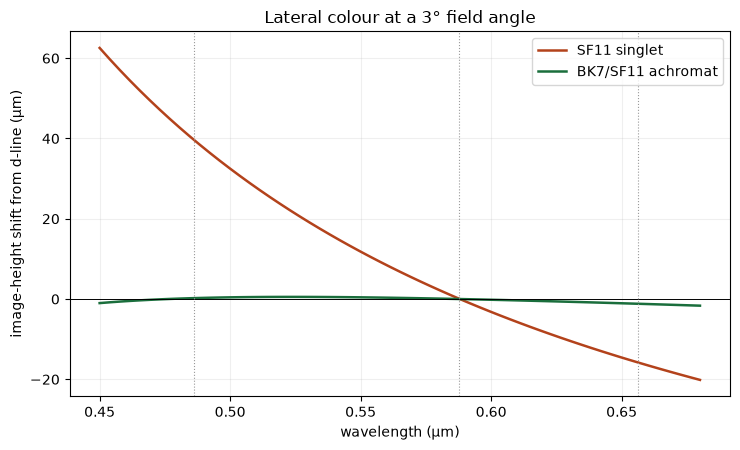

SF11 singlet         F-to-C image-height difference =  +55.47 µm
BK7/SF11 achromat    F-to-C image-height difference =   +1.40 µm


In [7]:
field_deg = 3.0
field_height_mm = abs(OBJECT_Z_MM) * np.tan(np.deg2rad(field_deg))

lateral = {s.name: lateral_color(s, sweep, field_height_mm=field_height_mm,
                                 reference_wavelength_um=D_LINE)
           for s in (singlet, achromat)}

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for (name, result), color in zip(lateral.items(), ("#b3421b", "#1a6e3c")):
    ax.plot(result.wavelengths_um, result.lateral_color_um, "-", color=color, lw=1.8,
            label=name)
ax.axhline(0, color="black", lw=0.7)
for line in REFERENCE_LINES:
    ax.axvline(line, color="#999999", ls=":", lw=0.8)
ax.set(xlabel="wavelength (µm)", ylabel="image-height shift from d-line (µm)",
       title=f"Lateral colour at a {field_deg:g}° field angle")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

for name, result in lateral.items():
    f_c = np.interp(F_LINE, result.wavelengths_um, result.lateral_color_um)
    c_c = np.interp(C_LINE, result.wavelengths_um, result.lateral_color_um)
    print(f"{name:20s} F-to-C image-height difference = {f_c - c_c:+7.2f} µm")

### Stop position, swept

Rebuilding the singlet with the stop at a range of distances ahead of the
lens confirms the rule directly: lateral colour is essentially zero with
the stop at the lens and grows steadily as the stop moves away, while
axial colour — which does not care where the chief ray crosses — stays
put.

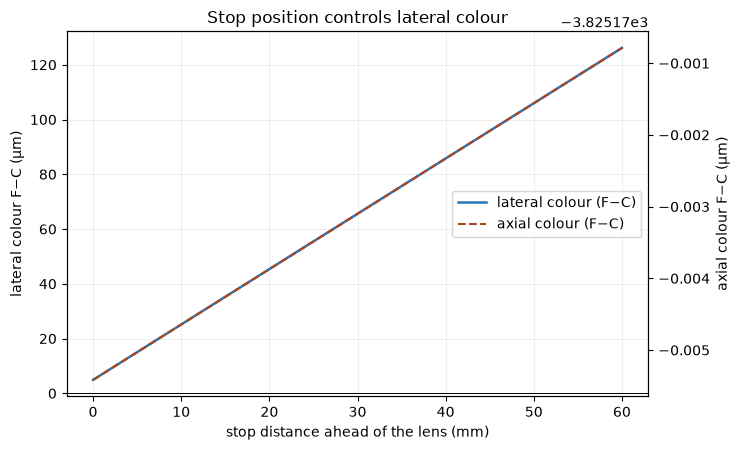

lateral colour at stop-on-lens:   +4.89 µm
lateral colour at 60 mm ahead:  +126.15 µm
axial colour, meanwhile, does not move at all: it varies by 0.00463 µm across the whole sweep


In [8]:
def with_stop_gap(system, gap_mm):
    """A copy of *system* with its stop moved to gap_mm ahead of the first lens."""
    shifted = copy.deepcopy(system)
    shifted.set_thickness(0, gap_mm)
    return shifted


stop_gaps = np.linspace(0.0, 60.0, 25)
lateral_vs_gap, axial_vs_gap = [], []
for gap in stop_gaps:
    variant = with_stop_gap(singlet, gap)
    result = lateral_color(variant, REFERENCE_LINES, field_height_mm=field_height_mm,
                           reference_wavelength_um=D_LINE)
    lateral_vs_gap.append(result.lateral_color_um[0] - result.lateral_color_um[2])
    focus = axial_color(variant, REFERENCE_LINES, reference_wavelength_um=D_LINE)
    axial_vs_gap.append((focus.focus_z_mm[0] - focus.focus_z_mm[2]) * 1e3)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(stop_gaps, lateral_vs_gap, "-", color="#2878b5", lw=1.8, label="lateral colour (F−C)")
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="stop distance ahead of the lens (mm)",
       ylabel="lateral colour F−C (µm)", title="Stop position controls lateral colour")
ax.grid(alpha=0.2)
twin = ax.twinx()
twin.plot(stop_gaps, axial_vs_gap, "--", color="#b3421b", lw=1.5,
          label="axial colour (F−C)")
twin.set_ylabel("axial colour F−C (µm)")
lines = ax.get_lines()[:1] + twin.get_lines()[:1]
ax.legend(lines, [line.get_label() for line in lines], loc="center right")
fig.tight_layout()
plt.show()

print(f"lateral colour at stop-on-lens: {lateral_vs_gap[0]:+7.2f} µm")
print(f"lateral colour at 60 mm ahead:  {lateral_vs_gap[-1]:+7.2f} µm")
print(f"axial colour, meanwhile, does not move at all: it varies by "
      f"{np.ptp(axial_vs_gap):.3g} µm across the whole sweep")

## 6 · Summary

| quantity | SF11 singlet | BK7/SF11 achromat | improvement |
|---|---|---|---|
| axial colour, F−C | −3826 µm | −56 µm | 68× |
| polychromatic RMS at the d-line focus | 87.3 µm | 5.5 µm | 16× |
| polychromatic RMS at its *own* best focus | 72.9 µm | 5.5 µm | 13× |
| lateral colour at 3°, F−C | +55.5 µm | +1.4 µm | 40× |

(The achromat's two RMS rows agree because its best focus *is* the d-line
focus — it has essentially nothing to refocus away.)

Three things worth carrying away:

1. **Dispersion, not index, is the culprit.** N-SF11's high index is what
   makes it a useful *corrector*; its low Abbe number is what makes it a
   terrible sole element.
2. **The achromat does not remove colour — it cancels it at two
   wavelengths.** What is left, the secondary spectrum, is a genuine
   limit of two-glass correction, not sloppy design. Beating it takes a
   third glass with anomalous partial dispersion (an apochromat).
3. **Axial and lateral colour are separately controllable.** Glass choice
   fixes the first; stop placement fixes the second. Section 5 shows them
   moving independently.

A caveat on the numbers: the dispersion model is the real measured
Sellmeier curve for both glasses, but the two *designs* are textbook
constructions built here for teaching, not manufactured prescriptions —
the achromat comes straight from the thin-lens condition with no
subsequent optimisation, so its residual spherical aberration is
untouched.